In [2]:
import matplotlib.pyplot as plt
import PcmPy as pcm
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys

ROOT =  Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl

plt.style.use('default')

Base directory found: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Base directory: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Atlases dir found: /Users/mnlmrc/Documents/GitHub/sensori-motor-prediction/data/atlases


In [3]:
experiment = 'smp2'
H = 'L'

force: tval=3.2106057951069467, pval=0.0034133860048000406


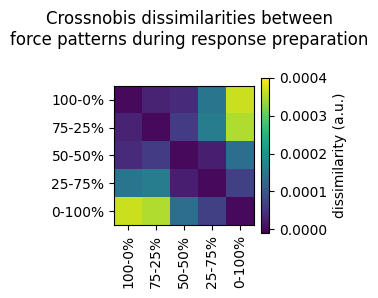

In [4]:
from vis import plot_dissimilarities

fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.00001, .0004

G = np.load(os.path.join(ROOT, 'data', 'encoding', f'G_obs.force.plan.npy'))
Df = pcm.G_to_dist(G)
fig, ax = plot_dissimilarities(fig, ax, None, Df, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=False, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()


M1
slope: -43.588288353206536, p = 0.306
intercept: 0.030060270986087805, p_intercept = 0.001
R2 = 0.087

S1
slope: -32.47334186924567, p = 0.453
intercept: 0.03990070014329524, p_intercept = 0.000
R2 = 0.048


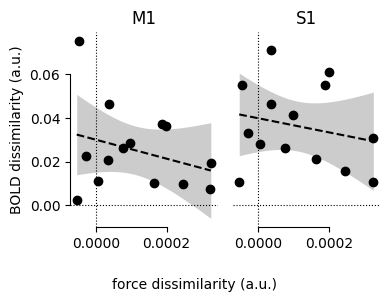

In [5]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

x = Df.mean(axis=(1, 2))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(ROOT, 'data', 'encoding',f'G_obs.plan.glm12.{H}.{roi}.npy'))
    D = np.array([pcm.G_to_dist(Gg) for Gg in G])
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('BOLD dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('force dissimilarity (a.u.)', fontsize=10)

fig.tight_layout()

plt.show()

In [6]:
filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat[(dat['cue']=='0-100%') | (dat['cue']=='0-100%')]
dat = dat.groupby(['sn']).mean(numeric_only=True).reset_index()
print('--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---')
print(f'{dat.forceDiff.mean()}+/-{dat.forceDiff.std() / np.sqrt(len(dat.sn.unique()))}')


--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---
0.05000936861742333+/-0.02505079810941822
